# Assigning clusterid Manually

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 33.1 MB/s eta 0:00:00


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.ML.Cluster import Butina
import numpy as np
import pandas as pd

# --- Load your data ---
df = pd.read_csv("https://raw.githubusercontent.com/kalyani-10/Heat-Stabilizer/main/Smiles_with_DFT.csv")

In [6]:
df.shape

(1552, 14)

In [4]:
from rdkit.Chem import Descriptors

def calculate_molecular_weight(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Descriptors.MolWt(mol)
        return None
    except:
        return None

df['Molecular_Weight'] = df['SMILES'].apply(calculate_molecular_weight)

# Display the first few rows with the new Molecular_Weight column
display(df[['SMILES', 'Molecular_Weight']].head())

[16:21:35] SMILES Parse Error: syntax error while parsing: Not
[16:21:35] SMILES Parse Error: check for mistakes around position 3:
[16:21:35] Not
[16:21:35] ~~^
[16:21:35] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[16:21:35] SMILES Parse Error: syntax error while parsing: Not
[16:21:35] SMILES Parse Error: check for mistakes around position 3:
[16:21:35] Not
[16:21:35] ~~^
[16:21:35] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[16:21:35] SMILES Parse Error: syntax error while parsing: Not
[16:21:35] SMILES Parse Error: check for mistakes around position 3:
[16:21:35] Not
[16:21:35] ~~^
[16:21:35] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'


,SMILES,Molecular_Weight
0,[Br][Pt+3]([Br])([Br])([Br])[Br],594.598
1,[Cu+],63.546
2,CCn1/c(=N\N=c2\sc3cc(S(=O)(=O)[O-])ccc3n2CC)sc...,512.616
3,COc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,236.355
4,Cc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,220.356


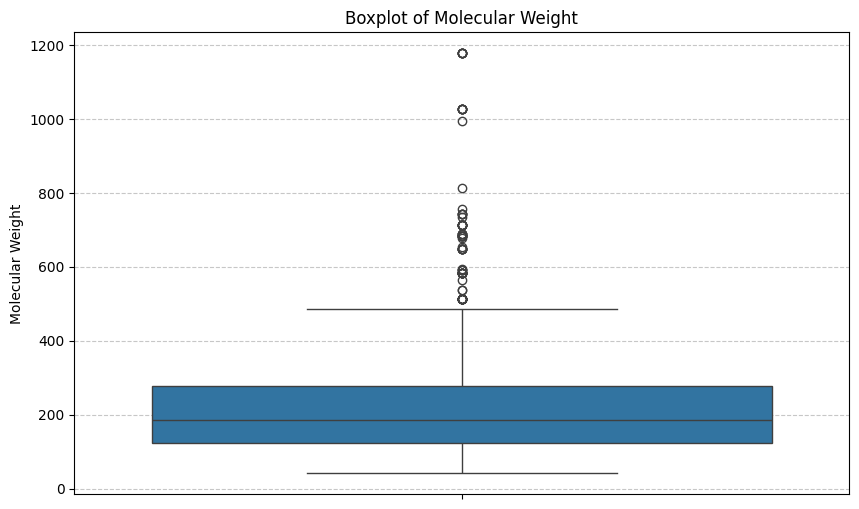

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Molecular_Weight'].dropna())
plt.title('Boxplot of Molecular Weight')
plt.ylabel('Molecular Weight')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
df['cluster_ID'] = df['Molecular_Weight'].apply(lambda x: 1 if x > 300 else 0)

display(df[['SMILES', 'Molecular_Weight', 'cluster_ID']].head())

,SMILES,Molecular_Weight,cluster_ID
0,[Br][Pt+3]([Br])([Br])([Br])[Br],594.598,1
1,[Cu+],63.546,0
2,CCn1/c(=N\N=c2\sc3cc(S(=O)(=O)[O-])ccc3n2CC)sc...,512.616,1
3,COc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,236.355,0
4,Cc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,220.356,0


In [16]:
cluster_counts = df['cluster_ID'].value_counts()
print("Number of molecules in each cluster:")
display(cluster_counts)

Number of molecules in each cluster:


,count
cluster_ID,
0,1315
1,237


In [17]:
from rdkit.Chem import Descriptors, Lipinski

def calculate_aromatic_rings(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Lipinski.NumAromaticRings(mol)
        return None
    except:
        return None

df['Aromatic_Rings'] = df['SMILES'].apply(calculate_aromatic_rings)

display(df[['SMILES', 'Aromatic_Rings', 'cluster_ID']].head())

[16:27:56] SMILES Parse Error: syntax error while parsing: Not
[16:27:56] SMILES Parse Error: check for mistakes around position 3:
[16:27:56] Not
[16:27:56] ~~^
[16:27:56] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[16:27:56] SMILES Parse Error: syntax error while parsing: Not
[16:27:56] SMILES Parse Error: check for mistakes around position 3:
[16:27:56] Not
[16:27:56] ~~^
[16:27:56] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[16:27:56] SMILES Parse Error: syntax error while parsing: Not
[16:27:56] SMILES Parse Error: check for mistakes around position 3:
[16:27:56] Not
[16:27:56] ~~^
[16:27:56] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'


,SMILES,Aromatic_Rings,cluster_ID
0,[Br][Pt+3]([Br])([Br])([Br])[Br],0.0,1
1,[Cu+],0.0,0
2,CCn1/c(=N\N=c2\sc3cc(S(=O)(=O)[O-])ccc3n2CC)sc...,4.0,1
3,COc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,1.0,0
4,Cc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,1.0,0


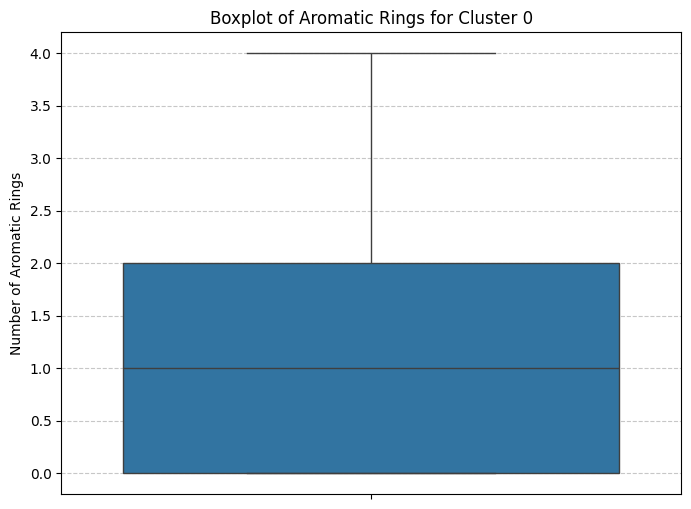

In [18]:
cluster_0_df = df[df['cluster_ID'] == 0]

plt.figure(figsize=(8, 6))
sns.boxplot(y=cluster_0_df['Aromatic_Rings'].dropna())
plt.title('Boxplot of Aromatic Rings for Cluster 0')
plt.ylabel('Number of Aromatic Rings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
# Assign cluster ID 2 for molecules in cluster 0 with more than 1 aromatic ring
df.loc[(df['cluster_ID'] == 0) & (df['Aromatic_Rings'] > 1), 'cluster_ID'] = 2

# Assign cluster ID 3 for molecules in cluster 0 with 1 or less aromatic rings
df.loc[(df['cluster_ID'] == 0) & (df['Aromatic_Rings'] <= 1), 'cluster_ID'] = 3

display(df[['SMILES', 'Aromatic_Rings', 'cluster_ID']].head())

,SMILES,Aromatic_Rings,cluster_ID
0,[Br][Pt+3]([Br])([Br])([Br])[Br],0.0,1
1,[Cu+],0.0,3
2,CCn1/c(=N\N=c2\sc3cc(S(=O)(=O)[O-])ccc3n2CC)sc...,4.0,1
3,COc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,1.0,3
4,Cc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,1.0,3


In [20]:
updated_cluster_counts = df['cluster_ID'].value_counts()
print("Number of molecules in each updated cluster:")
display(updated_cluster_counts)

Number of molecules in each updated cluster:


,count
cluster_ID,
3,721
0,339
2,255
1,237


In [21]:
df.to_csv('clustered_molecules.csv', index=False)
print("DataFrame saved to clustered_molecules.csv")

DataFrame saved to clustered_molecules.csv
